In [ ]:
# ==========================================
# BƯỚC 1: CÀI ĐẶT & TẢI DỮ LIỆU (KAGGLEHUB)
# ==========================================
!pip install -q kagglehub
import kagglehub
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

print("1. Đang tải dữ liệu...")
dataset_path = kagglehub.dataset_download("utkarshsaxenadn/fast-food-classification-dataset")
train_dir = os.path.join(dataset_path, "Fast Food Classification V2/Train")
valid_dir = os.path.join(dataset_path, "Fast Food Classification V2/Valid")
test_dir = os.path.join(dataset_path, "Fast Food Classification V2/Test")

1. Đang tải dữ liệu...
Using Colab cache for faster access to the 'fast-food-classification-dataset' dataset.


##  **BƯỚC 1: Chuẩn bị dữ liệu**

2. Đã chuẩn bị: Train(800), Valid(200), Test(200).
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


4. Bắt đầu huấn luyện và đánh giá (Mosaic) - Đã tối ưu hóa mượt mà...

Epoch [1/40] | Train Loss: 2.0456, Train Acc: 0.4838 | Valid Loss: 1.2652, Valid Acc: 0.6250
Epoch [2/40] | Train Loss: 1.2263, Train Acc: 0.8175 | Valid Loss: 0.8621, Valid Acc: 0.7700
Epoch [3/40] | Train Loss: 1.1709, Train Acc: 0.8938 | Valid Loss: 0.7759, Valid Acc: 0.7950
Epoch [4/40] | Train Loss: 0.9559, Train Acc: 0.9413 | Valid Loss: 0.7362, Valid Acc: 0.7750
Epoch [5/40] | Train Loss: 0.8464, Train Acc: 0.9688 | Valid Loss: 0.7311, Valid Acc: 0.8000
Epoch [6/40] | Train Loss: 0.7613, Train Acc: 0.9712 | Valid Loss: 0.7307, Valid Acc: 0.7700
Epoch [7/40] | Train Loss: 0.8431, Train Acc: 0.9825 | Valid Loss: 0.7096, Valid Acc: 0.7850
Epoch [8/40] | Train Loss: 0.7714, Train Acc: 0.9825 | Valid Loss: 0.7041, Valid Acc: 0.7750
Epoch [9/40] | Train Loss: 0.7537, Train Acc: 0.9888 | Valid Loss: 0.7015, Valid Acc: 0.7800
Epoch [10/40] | Train Loss: 0.8161, Train Acc: 0.9938 | Valid Loss: 0.6866, Valid Acc: 0.785

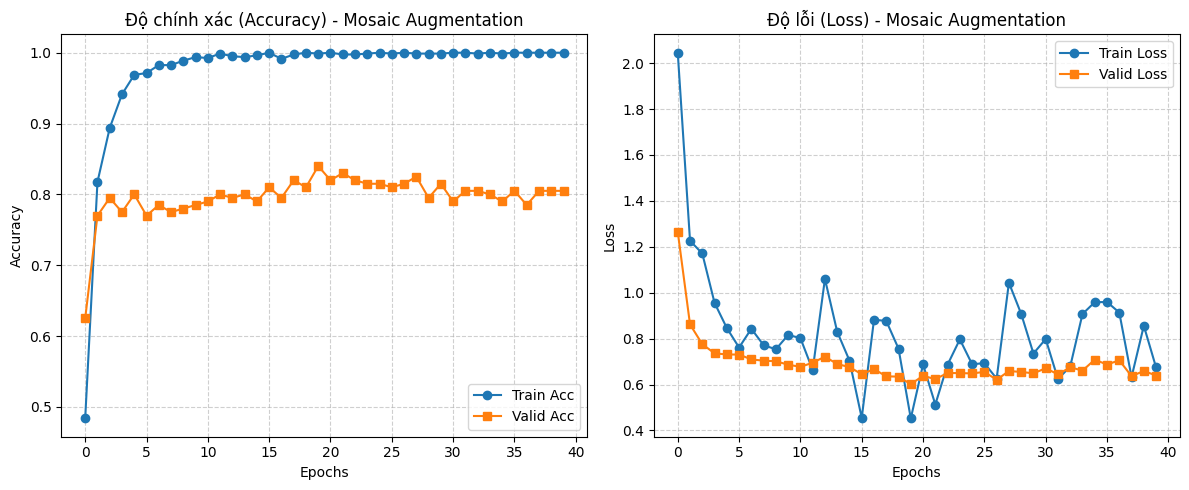

In [ ]:
from torchvision import transforms
import matplotlib.pyplot as plt

# ==========================================
# BƯỚC 2: HÀM MOSAIC & CHUẨN BỊ TẬP CON
# ==========================================

# Hàm Mosaic cho Classification (Ghép 4 ảnh thành 1)
def apply_mosaic(inputs, targets, img_size=224):
    batch_size = inputs.size(0)
    idx0 = torch.arange(batch_size)
    idx1 = torch.randperm(batch_size)
    idx2 = torch.randperm(batch_size)
    idx3 = torch.randperm(batch_size)

    new_inputs = torch.zeros_like(inputs)
    c = img_size // 2 # Điểm cắt ở giữa

    # Resize và ghép 4 góc
    new_inputs[:, :, 0:c, 0:c] = torch.nn.functional.interpolate(inputs[idx0], size=(c, c))
    new_inputs[:, :, 0:c, c:img_size] = torch.nn.functional.interpolate(inputs[idx1], size=(c, c))
    new_inputs[:, :, c:img_size, 0:c] = torch.nn.functional.interpolate(inputs[idx2], size=(c, c))
    new_inputs[:, :, c:img_size, c:img_size] = torch.nn.functional.interpolate(inputs[idx3], size=(c, c))

    return new_inputs, targets[idx0], targets[idx1], targets[idx2], targets[idx3]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dữ liệu và rút gọn số lượng
full_train = datasets.ImageFolder(train_dir, transform=transform)
full_valid = datasets.ImageFolder(valid_dir, transform=transform)
full_test = datasets.ImageFolder(test_dir, transform=transform)

train_idx = torch.randperm(len(full_train))[:800]
valid_idx = torch.randperm(len(full_valid))[:200]
test_idx = torch.randperm(len(full_test))[:200]

train_loader = DataLoader(Subset(full_train, train_idx), batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(Subset(full_valid, valid_idx), batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(Subset(full_test, test_idx), batch_size=32, shuffle=False, num_workers=2)

print(f"2. Đã chuẩn bị: Train(800), Valid(200), Test(200).")

# ==========================================
# BƯỚC 3: MÔ HÌNH RESNET18
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, len(full_train.classes))
model = model.to(device)
epochs = 40
mosaic_prob = 0.5
criterion = nn.CrossEntropyLoss()

# 1. GIẢM Learning Rate xuống 10 lần (1e-4) để AI học chậm lại và chắc chắn hơn
# Thêm weight_decay để chống nhiễu (Regularization)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# 2. THÊM Scheduler: Công cụ này sẽ tự động giảm từ từ Learning Rate qua từng Epoch
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

# ==========================================
# BƯỚC 4: HUẤN LUYỆN, VALIDATION VÀ VẼ BIỂU ĐỒ (MOSAIC)
# ==========================================

train_losses, valid_losses = [], []
train_accs, valid_accs = [], []

print("4. Bắt đầu huấn luyện và đánh giá (Mosaic) - Đã tối ưu hóa mượt mà...\n")
for epoch in range(epochs):
    # --- PHA 1: HUẤN LUYỆN ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        if np.random.rand() < mosaic_prob:
            inputs_m, t0, t1, t2, t3 = apply_mosaic(inputs, targets)
            outputs = model(inputs_m)

            loss = 0.25 * (criterion(outputs, t0) + criterion(outputs, t1) +
                           criterion(outputs, t2) + criterion(outputs, t3))
            _, predicted = outputs.max(1)
            correct_train += (predicted.eq(t0) | predicted.eq(t1) | predicted.eq(t2) | predicted.eq(t3)).sum().item()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            _, predicted = outputs.max(1)
            correct_train += predicted.eq(targets).sum().item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total_train += targets.size(0)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # --- PHA 2: ĐÁNH GIÁ (VALIDATION) ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_targets in valid_loader:
            val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)

            val_outputs = model(val_inputs)
            loss = criterion(val_outputs, val_targets)

            val_loss += loss.item()
            _, predicted = val_outputs.max(1)
            total_val += val_targets.size(0)
            correct_val += predicted.eq(val_targets).sum().item()

    epoch_val_loss = val_loss / len(valid_loader)
    epoch_val_acc = correct_val / total_val
    valid_losses.append(epoch_val_loss)
    valid_accs.append(epoch_val_acc)

    # Cập nhật Scheduler sau mỗi Epoch để từ từ bóp nhỏ Learning Rate
    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | Valid Loss: {epoch_val_loss:.4f}, Valid Acc: {epoch_val_acc:.4f}")
# ==========================================
# BƯỚC 5: VẼ BIỂU ĐỒ VÀ LƯU MÔ HÌNH
# ==========================================
print("\n--- ĐANG VẼ BIỂU ĐỒ ---")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ 1: Độ chính xác
ax1.plot(train_accs, label='Train Acc', color='tab:blue', marker='o')
ax1.plot(valid_accs, label='Valid Acc', color='tab:orange', marker='s')
ax1.set_title('Độ chính xác (Accuracy) - Mosaic Augmentation')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Biểu đồ 2: Độ lỗi (Loss)
ax2.plot(train_losses, label='Train Loss', color='tab:blue', marker='o')
ax2.plot(valid_losses, label='Valid Loss', color='tab:orange', marker='s')
ax2.set_title('Độ lỗi (Loss) - Mosaic Augmentation')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
import torch

# 1. Đặt tên cho file (nên ghi chú rõ thuật toán đã dùng để khỏi quên)
model_save_name = 'fastfood_resnet18_mosaic.pth'

# 2. Lệnh lưu "bộ não" (state_dict) của mô hình
torch.save(model.state_dict(), model_save_name)
print(f"Đã lưu trọng số vào file: {model_save_name}")

# 3. Kích hoạt trình duyệt tải file về máy tính
files.download(model_save_name)

Đã lưu trọng số vào file: fastfood_resnet18_mosaic.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>